### 1.4.2.1. Direction Fields

$$
\frac{dy}{dx} = f(x, y): \quad \text{at each point } (x,y) \text{ a lineal element has slope } f(x, y).
$$

**Explanation:**

A first-order equation in normal form $y' = f(x,y)$ assigns a **slope** $f(x,y)$ to every point of the plane. Drawing a short line segment (a *lineal element*) of that slope at each point of a grid produces a **direction field** (or slope field). Because any solution must be tangent to the field at every point, the field reveals the qualitative shape of solution curves — where they rise, fall, or level off — **without solving the equation**. This is the geometric picture behind [Euler's method](../09_Numerical_Methods/01_eulers_method.ipynb), which steps along the field, and behind the [existence and uniqueness](../01_Introduction/04_existence_and_uniqueness_of_solutions.ipynb) of the curve through a given point.

**Intuition:**

Solution curves flow tangent to the lineal elements, following the field like streamlines.

<p align="center">
  <img src="../../../Figures/01040201_direction_field_solution_curves.jpeg"
       alt="A direction field with three solution curves flowing tangent to the lineal elements"
       width="320">
</p>

**Numerical Example:**

Consider $\dfrac{dy}{dx} = x - y$. The slope at a point is just $f(x,y) = x - y$, so a small table of lineal-element slopes is

$$
\begin{array}{c|c}
(x, y) & \text{slope } f = x - y \\ \hline
(0, 0) & 0 \\
(1, 0) & 1 \\
(0, 1) & -1 \\
(2, 1) & 1 \\
(1, 1) & 0
\end{array}
$$

The points where the slope is the same value $c$ — the **isoclines** — are the lines $x - y = c$. Along $y = x$ (where $c = 0$) every element is horizontal. Following the field, solution curves descend toward and then run nearly parallel to the line $y = x - 1$, which is itself the solution corresponding to no transient. Indeed the equation is linear and its solutions are $y = x - 1 + Ce^{-x}$, confirming the qualitative reading.

In [1]:
import sympy as sp

x = sp.symbols("x")
y = sp.Function("y")
slope = lambda point_x, point_y: point_x - point_y

sample_points = [(0, 0), (1, 0), (0, 1), (2, 1), (1, 1)]
for point_x, point_y in sample_points:
    print(f"slope at ({point_x}, {point_y}) = {slope(point_x, point_y)}")

solution = sp.dsolve(sp.Eq(y(x).diff(x), x - y(x)), y(x))
print("solution family :", solution)

slope at (0, 0) = 0
slope at (1, 0) = 1
slope at (0, 1) = -1
slope at (2, 1) = 1
slope at (1, 1) = 0
solution family : Eq(y(x), C1*exp(-x) + x - 1)


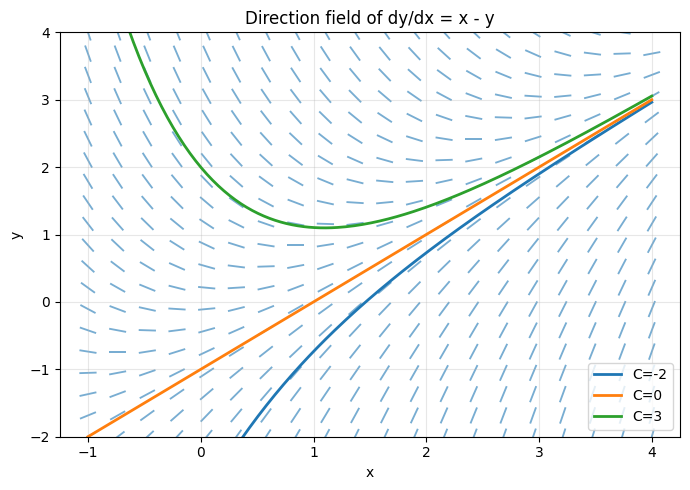

In [2]:
import numpy as np
import matplotlib.pyplot as plt

grid_x, grid_y = np.meshgrid(np.linspace(-1, 4, 20), np.linspace(-2, 4, 20))
field_slope = grid_x - grid_y
segment_length = 1 / np.sqrt(1 + field_slope**2)

plt.figure(figsize=(7, 5))
plt.quiver(grid_x, grid_y, segment_length, field_slope * segment_length,
           angles="xy", color="C0", alpha=0.6, headwidth=1, headlength=0, pivot="mid")
sample_x = np.linspace(-1, 4, 200)
for constant in (-2, 0, 3):
    plt.plot(sample_x, sample_x - 1 + constant * np.exp(-sample_x), linewidth=2, label=f"C={constant}")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Direction field of dy/dx = x - y")
plt.legend(); plt.grid(True, alpha=0.3); plt.ylim(-2, 4); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Existence and Uniqueness of Solutions](../01_Introduction/04_existence_and_uniqueness_of_solutions.ipynb) | [Next: Autonomous Equations and Stability ➡️](./02_autonomous_equations_and_stability.ipynb)